<h2> <strong> <span style="color: lightgreen"> Polars vs Pandas 🐼
</span>
</strong>
</h2>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



- **Linkedin Jobs and Skills:**
  - Pata comparar el rendimiento de las paqueterias Pandas y Polars se utiliza el data set de empleos de Linkedin que tiene una dimensión de 1,348,454  filas y 14 columnas.
  - Sitio web: [Kaggle]( https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024)







* <h3> <strong> <span style="color: darkgreen"> Carga de datos CSV
</strong>
</h4>

In [4]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Reading
path_data_link = fr'/content/drive/MyDrive/cursos-para-dictar/UDM/04_clase/linkedin_job_postings.csv'

In [5]:
%%time
df_pd_read = pd.read_csv(path_data_link) # pandas

CPU times: user 8.22 s, sys: 908 ms, total: 9.12 s
Wall time: 9.86 s


In [6]:
%%time
df_pl_read = pl.read_csv(path_data_link) # polars

CPU times: user 2.14 s, sys: 829 ms, total: 2.97 s
Wall time: 2 s


In [7]:
%%time
pd_time_read_csv = %timeit -n10 -r1 -o df_pd_read_csv= pd.read_csv(path_data_link)

9.93 s ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
CPU times: user 1min 22s, sys: 7.34 s, total: 1min 29s
Wall time: 1min 39s


In [8]:
%%time
pl_time_read_csv = %timeit -n10 -r1 -o df_pl_read_csv = pl.read_csv(path_data_link)

1.96 s ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
CPU times: user 24.6 s, sys: 3.93 s, total: 28.6 s
Wall time: 19.6 s


In [11]:
# Función para graficar

def bar_plot(pl_time, pd_time):
    data = {'Library': ['Polars', 'Pandas'],
            'Average Time (seconds)': [pl_time, pd_time]}
    df = pd.DataFrame(data)
    plt.figure(figsize=(8, 6))
    custom_palette = ["royalblue", "darkgrey"]
    sns.set(style="whitegrid")
    ax = sns.barplot(x='Library', y='Average Time (seconds)', data=df, palette= custom_palette)
    ax.set_title('Tiempo promedio de ejecución')
    ax.set_xlabel('Librería')
    ax.set_ylabel('Tiempo promedio (segundos)')

    # Annotate bars with values
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points')

    plt.show()

<ipython-input-11-9001d3409184>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Library', y='Average Time (seconds)', data=df, palette= custom_palette)


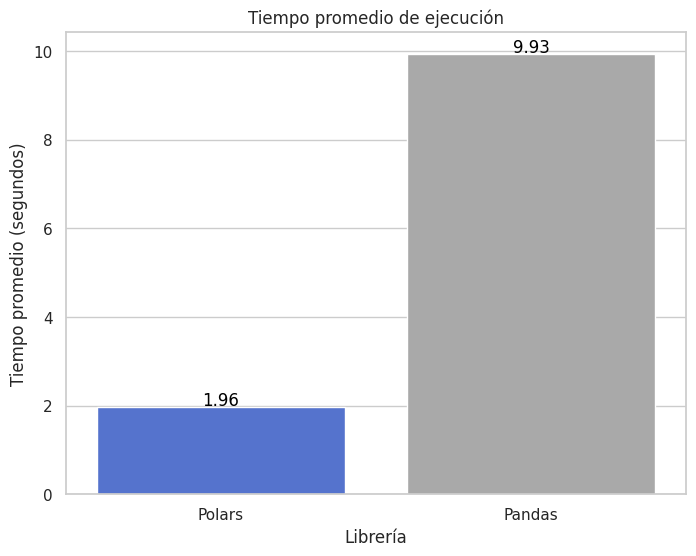

In [12]:
bar_plot(pl_time_read_csv.average, pd_time_read_csv.average)

* <h3> <strong> <span style="color: orange"> Filtros
</strong>
</h4>

In [13]:
#Filter performing
pd_time_filter = %timeit -n10 -r1 -o df_pd_read.query('job_type == "Remote"')
pl_time_filter = %timeit -n10 -r1 -o df_pl_read.filter(pl.col('job_type') == 'Remote')

49.3 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
21.9 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


<ipython-input-11-9001d3409184>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Library', y='Average Time (seconds)', data=df, palette= custom_palette)


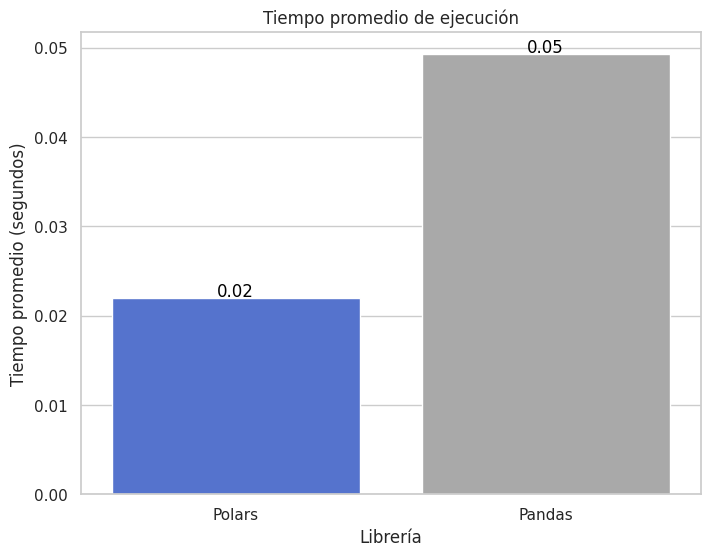

In [14]:
bar_plot(pl_time_filter.average, pd_time_filter.average)

* <h3> <strong> <span style="color: orange"> Creación de nuevas variables
</strong>
</h4>

In [18]:
#Polars

df_pl_read = df_pl_read.with_columns(
    pl.when(pl.col("search_country") == "United States")
      .then(pl.lit("Yes"))
      .otherwise(pl.lit("No"))
      .alias("In USA")
)

#Pandas
import numpy as np

df_pd_read['In USA'] = np.where(
    df_pd_read['search_country'] == "United States",
    'Yes',
    'No'
)

In [19]:
#Creating new features
pl_new_var = %timeit -n10 -r1 -o df_pl_new_var = df_pl_read.with_columns(pl.when(pl.col('search_country') == 'United States').then('Yes').otherwise('No').alias('In USA'))
pd_new_var = %timeit -n10 -r1 -o df_pd_read['In USA'] = pd.np.where(df_pd_read['search_country'] == "United States" , 'Yes', 'No')

ColumnNotFoundError: Yes

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'with_columns' <---
DF ["job_link", "last_processed_time", "got_summary", "got_ner"]; PROJECT */15 COLUMNS

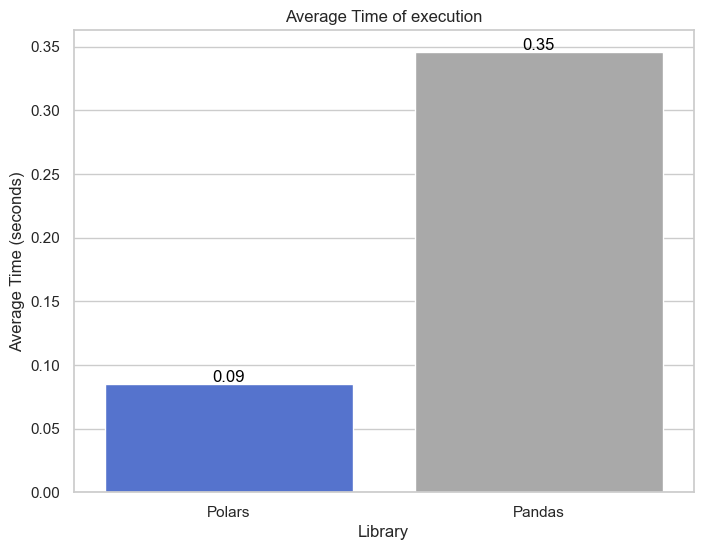

In [ ]:
bar_plot(pl_new_var.average, pd_new_var.average)

* <h3> <strong> <span style="color: orange"> Agrupamiento y funciones de agregación
</strong>
</h4>

In [ ]:
#Polars
df_grouped_pl = df_pl_read.groupby('job_level').agg(pl.count('job_level').alias('count_job_level'))
#Pandas
df_grouped_pd = df_pd_read.groupby('job_level').agg(count_job_level = ('job_level', 'count'))

C:\Users\diego.0661471\AppData\Local\Temp\ipykernel_38556\1399631349.py:2: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  df_grouped_pl = df_pl_read.groupby('job_level').agg(pl.count('job_level').alias('count_job_level'))


<magic-timeit>:1: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.


124 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
137 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


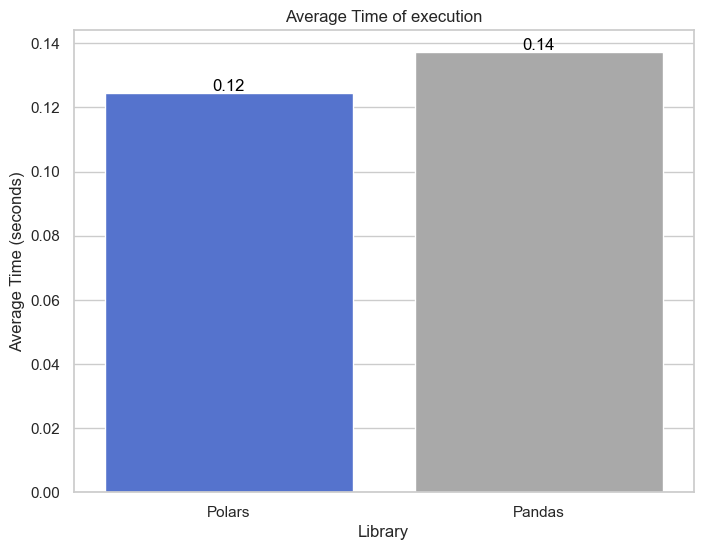

In [ ]:
#Grouping and agregation
pl_groupby = %timeit -n10 -r1 -o df_grouped_pl = df_pl_read.groupby('job_level').agg(pl.count('job_level').alias('count_job_level'))
pd_groupby = %timeit -n10 -r1 -o df_pd_read.groupby('job_level').agg(count_job_level = ('job_level', 'count'))
#Plot
bar_plot(pl_groupby.average, pd_groupby.average)